# Notebook to train the model for gender classification

### 1. Import

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import precision_score, recall_score, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from shoppingassistant.helper_functions import get_image_path


### 2. Load data and remove unwanted categories

In [13]:
# Load data
NOTEBOOK_DIR = Path().resolve().parent  # -> notebooks/my_notebook

df = pd.read_csv(NOTEBOOK_DIR/'raw_data/articles_filtered.csv')
images_base = NOTEBOOK_DIR/'raw_data/images_filtered'

In [14]:
# Remove unwanted categories
classes_to_remove = ['Sport',  'Divided']
df = df[~df['index_group_name'].isin(classes_to_remove)].reset_index(drop=True)

print(f"\n📊 Gender distribution after combining:")
print(df['index_group_name'].value_counts())
print(f"\nTotal images: {len(df)}")
print(f"Number of categories: {df['index_group_name'].nunique()}")


📊 Gender distribution after combining:
index_group_name
Baby/Children    2180
Ladieswear       2051
Menswear          661
Name: count, dtype: int64

Total images: 4892
Number of categories: 3


### 3. Add Image paths

In [15]:
def get_image_path_safe(article_id):
    try:
        return get_image_path(article_id)
    except:
        return None

df['image_path'] = df['article_id'].apply(get_image_path_safe)
df = df.dropna(subset=['image_path'])

print(f"Images found: {len(df)}")

Images found: 4892


### 4. Create Category List

In [16]:
# Get sorted list of categories
categories = sorted(df['index_group_name'].unique())
num_classes = len(categories)

print(f"\n🏷️ Categories ({num_classes}): {categories}")

# Create simple mapping
category_to_idx = {cat: idx for idx, cat in enumerate(categories)}
print(f"\nCategory mapping: {category_to_idx}")

# Add label column
df['label'] = df['index_group_name'].map(category_to_idx)


🏷️ Categories (3): ['Baby/Children', 'Ladieswear', 'Menswear']

Category mapping: {'Baby/Children': 0, 'Ladieswear': 1, 'Menswear': 2}


### 5. Split Data for Training and Testing

In [17]:
# Split data: 80% train, 10% val, 10% test
train_val_df, test_df = train_test_split(
    df, test_size=0.1, stratify=df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.11, stratify=train_val_df['label'], random_state=42
)

print(f"  Data split:")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")
print(f"  Test:  {len(test_df)} images")

  Data split:
  Train: 3917 images
  Val:   485 images
  Test:  490 images


### 6. Oversample Menswear

In [18]:
menswear_label_id = category_to_idx['Menswear']
menswear_df = train_df[train_df["label"] == menswear_label_id]
menswear_df

oversample_factor = 3

menswear_oversampled = pd.concat(
    [menswear_df] * oversample_factor,
    ignore_index=True
)


train_df_balanced = pd.concat(
    [train_df, menswear_oversampled],
    ignore_index=True
)

print(train_df_balanced['index_group_name'].value_counts())


index_group_name
Menswear         2116
Baby/Children    1746
Ladieswear       1642
Name: count, dtype: int64


### 7. Compute weights


In [19]:
# Compute class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df_balanced['label']
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0507827415043909), 1: np.float64(1.1173365814047909), 2: np.float64(0.867044738500315)}


### 8. Data Generators with EfficientNet Preprocessing

In [20]:
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    train_df_balanced, x_col='image_path', y_col='index_group_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='index_group_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='index_group_name',
    target_size=target_size, class_mode='sparse', batch_size=32, shuffle=False
)

Found 5504 validated image filenames belonging to 3 classes.
Found 485 validated image filenames belonging to 3 classes.
Found 490 validated image filenames belonging to 3 classes.


### 9. Build and compile model using pre-trained model

In [33]:
# Build model
'''
data_augmentation = Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomContrast(0.1),
        ])
'''

base_model = EfficientNetB1(
    weights="imagenet",
    include_top=False,
    input_shape = target_size + (3,)
)
base_model.trainable = False   # Freeze for first stage
input_shape = target_size + (3,)
inputs = layers.Input(shape=input_shape)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

#x = layers.Dense(512, activation='relu')(x)
#x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)


outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model built and compiled")


Model built and compiled


### 10. Train model

In [22]:
NOTEBOOK_DIR = Path().resolve().parent  # -> notebooks/my_notebook
MODELS_DIR = NOTEBOOK_DIR/"models"
MODEL_PATH = MODELS_DIR/"gender_classifier.keras"

epochs = 60

callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
        ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor="val_accuracy", mode="max")
    ]

print("🚀 Training started...")
history = model.fit(train_generator,
                validation_data=val_generator,
                epochs=epochs,
                class_weight=class_weights,
                callbacks=callbacks,
                verbose=1)

print("🎉 Training complete!")
print(f"Model saved at {MODEL_PATH}")


🚀 Training started...
Epoch 1/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 492ms/step - accuracy: 0.6931 - loss: 0.7223 - val_accuracy: 0.7134 - val_loss: 0.6480 - learning_rate: 0.0010
Epoch 2/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.7818 - loss: 0.5412 - val_accuracy: 0.7588 - val_loss: 0.5316 - learning_rate: 0.0010
Epoch 3/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 79s 459ms/step - accuracy: 0.8163 - loss: 0.4699 - val_accuracy: 0.7876 - val_loss: 0.5424 - learning_rate: 0.0010
Epoch 4/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 79s 460ms/step - accuracy: 0.8387 - loss: 0.4145 - val_accuracy: 0.7897 - val_loss: 0.5392 - learning_rate: 0.0010
Epoch 5/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.8576 - loss: 0.3626 - val_accuracy: 0.7959 - val_loss: 0.5473 - learning_rate: 0.0010
Epoch 6/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.8679 - loss: 0.3502 - val_accuracy: 0.8227 - val_loss: 0.5291 - learning_rate: 0.0010
Epoch 7/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 85s 491m

### 11. Evaluate model

In [23]:
loss, accuracy = model.evaluate(test_generator)

# Get predictions
y_pred = model.predict(test_generator)
y_pred_labels = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

precision = precision_score(y_true, y_pred_labels, average='macro')
recall = recall_score(y_true, y_pred_labels, average='macro')

print(f"{'='* 100}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"{'='* 100}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 439ms/step - accuracy: 0.8327 - loss: 0.4467
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 507ms/step
Accuracy: 83.27%
precision: 0.7943556816875202
recall: 0.8351277988759062


### 12. Classification Report

In [24]:
class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred_labels,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

Baby/Children       0.87      0.89      0.88       218
   Ladieswear       0.90      0.77      0.83       206
     Menswear       0.62      0.85      0.71        66

     accuracy                           0.83       490
    macro avg       0.79      0.84      0.81       490
 weighted avg       0.85      0.83      0.84       490



### 13. Plot accuracy and loss

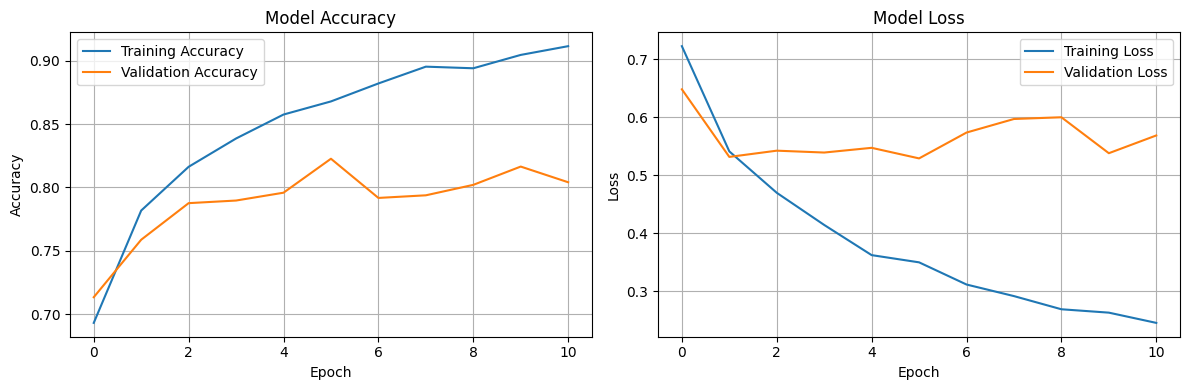

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 14. Model prediction from our data

[[0.01306273 0.10100555 0.8859318 ]]


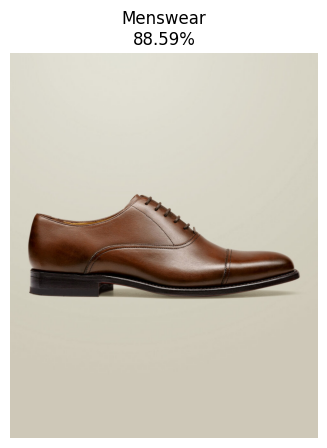


🔮 Prediction: Menswear
   Confidence: 88.59%


In [34]:
# Test on web image
import requests
from io import BytesIO
from tensorflow.keras.preprocessing.image import img_to_array

# Load model
model = load_model(NOTEBOOK_DIR/'models/gender_classifier.keras')

# Download test image
url = "https://www.charlestyrwhitt.com/dw/image/v2/AAWJ_PRD/on/demandware.static/-/Sites-ctshirts-master/default/dwfc3f7a1b/hi-res/SHC0246DTN_SIDE.jpg?sw=960&sh=1200"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Preprocess
img_resized = img.resize((224, 224))
img_array = img_to_array(img_resized)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)
print(prediction)
predicted_idx = np.argmax(prediction[0])
confidence = prediction[0][predicted_idx]
categories = ['Baby/Children', 'Ladieswear', 'Menswear']
predicted_category = categories[predicted_idx]

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{predicted_category}\n{confidence:.2%}")
plt.axis('off')
plt.show()

print(f"\n🔮 Prediction: {predicted_category}")
print(f"   Confidence: {confidence:.2%}")